# 03 - Feature and Descriptor Case Study

This notebook is the report-style comparison page for one panorama scene. It uses the same two input images for every method, then compares local-feature pipelines by their keypoints, matches, RANSAC inliers, reprojection error, runtime, match visualizations, and final pairwise panorama output.

**Scope note:** this is a single-scene, adjacent-pair case study. It is not the full-dataset benchmark yet; the same script structure is kept so we can extend it later to batch all scenes and show how the database looks after each panorama-stitching step.

**Input condition:** this notebook reads the saved preprocessing output from `data/preprocessing/<split>/feature_gray/<scene>`. It does not apply CLAHE, blur, sharpening, denoising, or any other preprocessing inside this notebook. Every feature pipeline receives the same already preprocessed image pair.

## Objective

This case study compares feature and descriptor pipelines on one preprocessed adjacent image pair. The goal is to identify which pipeline gives the most stable matches, strongest homography, and most usable pairwise panorama for this scene.

Pipelines compared:

- SIFT
- ORB
- Harris + ORB
- Harris + HOG
- AKAZE
- BRISK

## 1. Setup

In [1]:
from __future__ import annotations

import json
import math
import re
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown:
        def __init__(self, text: str) -> None:
            self.text = text

        def __str__(self) -> str:
            return self.text

    def display(value) -> None:
        print(value)


cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import load_scene_meta, ordered_scene_files


PREPROCESSING_ROOT = PROJECT_ROOT / "data" / "preprocessing"
SPLIT_ROOT = PROJECT_ROOT / "data" / "split"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "case_study"

# Change these two values when you want a different report page.
SPLIT_NAME = "development"
INPUT_KIND = "feature_gray"
SCENE_ID = "scene_32"
PAIR_INDEX = 2

# Safety resize only. Preprocessing itself is not performed in this notebook.
MAX_PROCESS_WIDTH = 1600
MAX_DISPLAY_WIDTH = 900

RANSAC_REPROJ_THRESHOLD = 4.0
MAX_PANORAMA_PIXELS = 45_000_000

np.random.seed(7)
cv2.setRNGSeed(7)
try:
    cv2.setNumThreads(1)
except Exception:
    pass

print("Project root:", PROJECT_ROOT)
print("Preprocessing root:", PREPROCESSING_ROOT)
print("OpenCV version:", cv2.__version__)
print("SIFT available:", hasattr(cv2, "SIFT_create"))
print("Matplotlib available:", HAS_MATPLOTLIB)


Project root: C:\Users\PC\Downloads\Project
Preprocessing root: C:\Users\PC\Downloads\Project\data\preprocessing
OpenCV version: 4.9.0
SIFT available: True
Matplotlib available: True


## 2. Selected Scene Pair

In [2]:
def resize_keep_aspect(image: np.ndarray, max_width: int) -> tuple[np.ndarray, float]:
    height, width = image.shape[:2]
    if width <= max_width:
        return image.copy(), 1.0
    scale = max_width / float(width)
    resized = cv2.resize(
        image,
        (max_width, int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )
    return resized, scale


def bgr_to_rgb(image: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def safe_slug(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")


scene_dir = PREPROCESSING_ROOT / SPLIT_NAME / INPUT_KIND / SCENE_ID
meta_scene_dir = SPLIT_ROOT / SPLIT_NAME / SCENE_ID
meta = load_scene_meta(meta_scene_dir)

if not scene_dir.exists():
    raise FileNotFoundError(
        f"Preprocessed scene folder not found: {scene_dir}. "
        "Run scripts/apply_preprocessing.py for this split before running the case study."
    )

ordered_files, reference_files, _, used_meta_order = ordered_scene_files(scene_dir)

if len(ordered_files) < 2:
    raise ValueError(f"{scene_dir} does not contain at least two ordered images.")

if PAIR_INDEX < 0 or PAIR_INDEX + 1 >= len(ordered_files):
    raise ValueError(f"PAIR_INDEX={PAIR_INDEX} is outside the available adjacent pairs.")

image_a_path = ordered_files[PAIR_INDEX]
image_b_path = ordered_files[PAIR_INDEX + 1]

image_a_full = cv2.imread(str(image_a_path), cv2.IMREAD_COLOR)
image_b_full = cv2.imread(str(image_b_path), cv2.IMREAD_COLOR)

if image_a_full is None:
    raise ValueError(f"Could not read {image_a_path}")
if image_b_full is None:
    raise ValueError(f"Could not read {image_b_path}")

image_a, scale_a = resize_keep_aspect(image_a_full, MAX_PROCESS_WIDTH)
image_b, scale_b = resize_keep_aspect(image_b_full, MAX_PROCESS_WIDTH)

gray_a = cv2.cvtColor(image_a, cv2.COLOR_BGR2GRAY)
gray_b = cv2.cvtColor(image_b, cv2.COLOR_BGR2GRAY)

case_dir = OUTPUT_ROOT / SPLIT_NAME / SCENE_ID / f"pair_{PAIR_INDEX + 1:02d}"
matches_dir = case_dir / "matches"
panoramas_dir = case_dir / "panoramas"
for directory in [case_dir, matches_dir, panoramas_dir]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Split: {SPLIT_NAME}")
print(f"Scene: {SCENE_ID}")
print(f"Input kind: {INPUT_KIND}")
print(f"Preprocessed input folder: {scene_dir.relative_to(PROJECT_ROOT)}")
print(f"Metadata folder: {meta_scene_dir.relative_to(PROJECT_ROOT)}")
print(f"Pair: {image_a_path.name} -> {image_b_path.name}")
print(f"Saved A shape: {image_a_full.shape}, notebook input A shape: {image_a.shape}, scale={scale_a:.3f}")
print(f"Saved B shape: {image_b_full.shape}, notebook input B shape: {image_b.shape}, scale={scale_b:.3f}")
print(f"Output folder: {case_dir.relative_to(PROJECT_ROOT)}")


Split: development
Scene: scene_32
Input kind: feature_gray
Preprocessed input folder: data\preprocessing\development\feature_gray\scene_32
Metadata folder: data\split\development\scene_32
Pair: img_03.png -> img_04.png
Saved A shape: (3555, 1600, 3), notebook input A shape: (3555, 1600, 3), scale=1.000
Saved B shape: (3555, 1600, 3), notebook input B shape: (3555, 1600, 3), scale=1.000
Output folder: outputs\case_study\development\scene_32\pair_03


## 3. Preprocessed Input Pair

### scene_32: Outdoor scene

- Dataset category: **hard_valid**
- Difficulty: **hard**
- Scene notes: Close range gate sequence dominated by repeated lattice bars and similar red flag shapes. Pairwise matching is mostly OK/strong and exposure is steady, but repeated OpenCV runs produce different panorama widths, making this a hard-valid repeated-pattern case.
- Difficulty cues: repeated patterns
- Feature input: `data/preprocessing/development/feature_gray/scene_32`

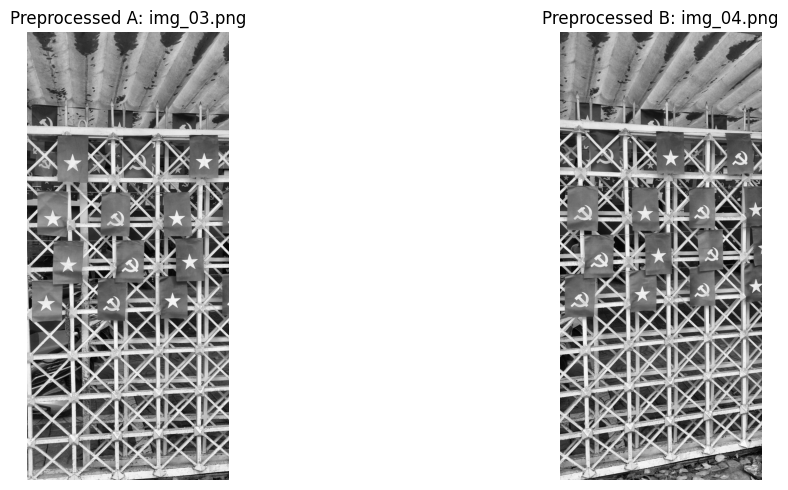

In [3]:
scene_type = meta.get("type", "unknown")
category = meta.get("category", "unknown")
difficulty = meta.get("difficulty", "unknown")
notes = meta.get("notes", "No scene notes were provided.")

difficulty_flags = [
    ("has_motion_blur", "motion blur"),
    ("has_low_texture", "low texture"),
    ("has_repeated_patterns", "repeated patterns"),
    ("has_moving_objects", "moving objects"),
    ("has_parallax", "parallax"),
    ("has_exposure_change", "exposure change"),
    ("has_insufficient_overlap", "insufficient overlap"),
]
active_flags = [label for key, label in difficulty_flags if meta.get(key)]
if not active_flags and meta.get("issues"):
    active_flags = [str(issue) for issue in meta.get("issues", [])]
if not active_flags:
    active_flags = ["no major difficulty flags in metadata"]

display(
    Markdown(
        f"### {SCENE_ID}: {scene_type.title()} scene\n\n"
        f"- Dataset category: **{category}**\n"
        f"- Difficulty: **{difficulty}**\n"
        f"- Scene notes: {notes}\n"
        f"- Difficulty cues: {', '.join(active_flags)}\n"
        f"- Feature input: `data/preprocessing/{SPLIT_NAME}/{INPUT_KIND}/{SCENE_ID}`"
    )
)

if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, image, title in [
        (axes[0], image_a, f"Preprocessed A: {image_a_path.name}"),
        (axes[1], image_b, f"Preprocessed B: {image_b_path.name}"),
    ]:
        ax.imshow(bgr_to_rgb(image))
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Matplotlib is not installed, so the image preview is skipped in this environment.")
    print("Preprocessed image A:", image_a_path)
    print("Preprocessed image B:", image_b_path)


## 4. Compared Pipelines

The table below is produced from measured values in this notebook. For fairness, all pipelines use the same preprocessed input pair and the same geometric verification step: homography estimation with RANSAC.

In [4]:
def harris_keypoints(
    gray: np.ndarray,
    max_corners: int = 1500,
    quality_level: float = 0.01,
    min_distance: float = 8.0,
    block_size: int = 3,
    k: float = 0.04,
    keypoint_size: float = 31.0,
) -> list[cv2.KeyPoint]:
    corners = cv2.goodFeaturesToTrack(
        gray,
        maxCorners=max_corners,
        qualityLevel=quality_level,
        minDistance=min_distance,
        blockSize=block_size,
        useHarrisDetector=True,
        k=k,
    )
    if corners is None:
        return []
    keypoints: list[cv2.KeyPoint] = []
    for point in corners.reshape(-1, 2):
        x, y = point
        keypoints.append(cv2.KeyPoint(float(x), float(y), keypoint_size))
    return keypoints


def compute_hog_descriptors(
    gray: np.ndarray,
    keypoints: list[cv2.KeyPoint],
    patch_size: int = 32,
    cells_per_side: int = 4,
    bins: int = 8,
) -> tuple[list[cv2.KeyPoint], np.ndarray | None]:
    if not keypoints:
        return [], None

    half = patch_size // 2
    pad = half + 2
    padded = cv2.copyMakeBorder(gray, pad, pad, pad, pad, cv2.BORDER_REFLECT101)
    gx = cv2.Sobel(padded, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(padded, cv2.CV_32F, 0, 1, ksize=3)
    magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=False)

    cell_size = patch_size // cells_per_side
    bin_width = (2.0 * np.pi) / bins

    kept_keypoints: list[cv2.KeyPoint] = []
    descriptors: list[np.ndarray] = []

    for keypoint in keypoints:
        center_x = int(round(keypoint.pt[0])) + pad
        center_y = int(round(keypoint.pt[1])) + pad
        y0, y1 = center_y - half, center_y + half
        x0, x1 = center_x - half, center_x + half
        patch_mag = magnitude[y0:y1, x0:x1]
        patch_ang = angle[y0:y1, x0:x1]

        if patch_mag.shape != (patch_size, patch_size):
            continue

        feature_parts: list[np.ndarray] = []
        for cy in range(cells_per_side):
            for cx in range(cells_per_side):
                cell_mag = patch_mag[
                    cy * cell_size : (cy + 1) * cell_size,
                    cx * cell_size : (cx + 1) * cell_size,
                ]
                cell_ang = patch_ang[
                    cy * cell_size : (cy + 1) * cell_size,
                    cx * cell_size : (cx + 1) * cell_size,
                ]
                cell_bins = np.floor(cell_ang / bin_width).astype(np.int32) % bins
                hist = np.zeros(bins, dtype=np.float32)
                for bin_index in range(bins):
                    hist[bin_index] = float(cell_mag[cell_bins == bin_index].sum())
                feature_parts.append(hist)

        descriptor = np.concatenate(feature_parts).astype(np.float32)
        descriptor /= np.linalg.norm(descriptor) + 1e-7
        descriptor = np.clip(descriptor, 0.0, 0.2)
        descriptor /= np.linalg.norm(descriptor) + 1e-7
        descriptors.append(descriptor)
        kept_keypoints.append(keypoint)

    if not descriptors:
        return [], None
    return kept_keypoints, np.vstack(descriptors).astype(np.float32)


def detect_and_describe(gray: np.ndarray, pipeline: dict) -> tuple[list[cv2.KeyPoint], np.ndarray | None]:
    kind = pipeline["kind"]

    if kind == "opencv":
        detector = pipeline["factory"]()
        keypoints, descriptors = detector.detectAndCompute(gray, None)
        return list(keypoints or []), descriptors

    if kind == "harris_orb":
        keypoints = harris_keypoints(gray)
        if not keypoints:
            return [], None
        orb = cv2.ORB_create(nfeatures=3000)
        computed_keypoints, descriptors = orb.compute(gray, keypoints)
        return list(computed_keypoints or []), descriptors

    if kind == "harris_hog":
        keypoints = harris_keypoints(gray)
        return compute_hog_descriptors(gray, keypoints)

    raise ValueError(f"Unknown pipeline kind: {kind}")


PIPELINES = [
    {
        "name": "SIFT",
        "kind": "opencv",
        "factory": lambda: cv2.SIFT_create(nfeatures=3500),
        "norm": cv2.NORM_L2,
        "ratio": 0.75,
    },
    {
        "name": "ORB",
        "kind": "opencv",
        "factory": lambda: cv2.ORB_create(nfeatures=4000, fastThreshold=10),
        "norm": cv2.NORM_HAMMING,
        "ratio": 0.75,
    },
    {
        "name": "Harris + ORB",
        "kind": "harris_orb",
        "norm": cv2.NORM_HAMMING,
        "ratio": 0.75,
    },
    {
        "name": "Harris + HOG",
        "kind": "harris_hog",
        "norm": cv2.NORM_L2,
        "ratio": 0.75,
    },
    {
        "name": "AKAZE",
        "kind": "opencv",
        "factory": lambda: cv2.AKAZE_create(),
        "norm": cv2.NORM_HAMMING,
        "ratio": 0.75,
    },
    {
        "name": "BRISK",
        "kind": "opencv",
        "factory": lambda: cv2.BRISK_create(),
        "norm": cv2.NORM_HAMMING,
        "ratio": 0.75,
    },
]


## 5. Matching and Homography Evaluation

In [5]:
def match_descriptors(
    descriptors_a: np.ndarray | None,
    descriptors_b: np.ndarray | None,
    norm_type: int,
    ratio: float,
) -> tuple[list[tuple[cv2.DMatch, ...]], list[cv2.DMatch]]:
    if descriptors_a is None or descriptors_b is None:
        return [], []
    if len(descriptors_a) < 2 or len(descriptors_b) < 2:
        return [], []

    matcher = cv2.BFMatcher(norm_type, crossCheck=False)
    knn_matches = matcher.knnMatch(descriptors_a, descriptors_b, k=2)

    good_matches: list[cv2.DMatch] = []
    for match_pair in knn_matches:
        if len(match_pair) < 2:
            continue
        best, second = match_pair
        if best.distance < ratio * second.distance:
            good_matches.append(best)
    return knn_matches, good_matches


def estimate_homography(
    keypoints_a: list[cv2.KeyPoint],
    keypoints_b: list[cv2.KeyPoint],
    good_matches: list[cv2.DMatch],
) -> tuple[np.ndarray | None, np.ndarray, float, float]:
    if len(good_matches) < 4:
        return None, np.zeros(len(good_matches), dtype=bool), np.nan, np.nan

    src = np.float32([keypoints_a[match.queryIdx].pt for match in good_matches]).reshape(-1, 1, 2)
    dst = np.float32([keypoints_b[match.trainIdx].pt for match in good_matches]).reshape(-1, 1, 2)

    homography, mask = cv2.findHomography(src, dst, cv2.RANSAC, RANSAC_REPROJ_THRESHOLD)
    if homography is None or mask is None:
        return None, np.zeros(len(good_matches), dtype=bool), np.nan, np.nan

    inlier_mask = mask.ravel().astype(bool)
    if not np.any(inlier_mask):
        return homography, inlier_mask, np.nan, np.nan

    projected = cv2.perspectiveTransform(src[inlier_mask], homography)
    target = dst[inlier_mask]
    errors = np.linalg.norm(projected.reshape(-1, 2) - target.reshape(-1, 2), axis=1)
    return homography, inlier_mask, float(np.mean(errors)), float(np.median(errors))


def crop_to_content(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return image
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    return image[y0:y1, x0:x1]


def build_pair_panorama(
    image_a_bgr: np.ndarray,
    image_b_bgr: np.ndarray,
    homography_a_to_b: np.ndarray | None,
) -> tuple[np.ndarray | None, str]:
    if homography_a_to_b is None:
        return None, "No homography"

    height_a, width_a = image_a_bgr.shape[:2]
    height_b, width_b = image_b_bgr.shape[:2]

    corners_a = np.float32(
        [[0, 0], [width_a, 0], [width_a, height_a], [0, height_a]]
    ).reshape(-1, 1, 2)
    corners_b = np.float32(
        [[0, 0], [width_b, 0], [width_b, height_b], [0, height_b]]
    ).reshape(-1, 1, 2)

    warped_corners_a = cv2.perspectiveTransform(corners_a, homography_a_to_b)
    all_corners = np.concatenate([warped_corners_a, corners_b], axis=0)
    min_xy = np.floor(all_corners.min(axis=0).ravel()).astype(int)
    max_xy = np.ceil(all_corners.max(axis=0).ravel()).astype(int)

    min_x, min_y = int(min_xy[0]), int(min_xy[1])
    max_x, max_y = int(max_xy[0]), int(max_xy[1])
    canvas_width = max_x - min_x
    canvas_height = max_y - min_y

    if canvas_width <= 0 or canvas_height <= 0:
        return None, "Invalid panorama canvas"
    if canvas_width * canvas_height > MAX_PANORAMA_PIXELS:
        return None, f"Panorama canvas too large: {canvas_width}x{canvas_height}"

    offset = np.array(
        [[1.0, 0.0, -min_x], [0.0, 1.0, -min_y], [0.0, 0.0, 1.0]],
        dtype=np.float64,
    )

    warped_a = cv2.warpPerspective(
        image_a_bgr,
        offset @ homography_a_to_b,
        (canvas_width, canvas_height),
    )
    mask_a = cv2.warpPerspective(
        np.full((height_a, width_a), 255, dtype=np.uint8),
        offset @ homography_a_to_b,
        (canvas_width, canvas_height),
    ) > 0

    canvas_b = np.zeros_like(warped_a)
    mask_b = np.zeros((canvas_height, canvas_width), dtype=bool)
    tx, ty = -min_x, -min_y
    canvas_b[ty : ty + height_b, tx : tx + width_b] = image_b_bgr
    mask_b[ty : ty + height_b, tx : tx + width_b] = True

    panorama = np.zeros_like(warped_a)
    only_a = mask_a & ~mask_b
    only_b = mask_b & ~mask_a
    overlap = mask_a & mask_b

    panorama[only_a] = warped_a[only_a]
    panorama[only_b] = canvas_b[only_b]
    panorama[overlap] = (
        0.5 * warped_a[overlap].astype(np.float32)
        + 0.5 * canvas_b[overlap].astype(np.float32)
    ).astype(np.uint8)

    content_mask = mask_a | mask_b
    return crop_to_content(panorama, content_mask), "OK"


def classify_result(
    homography: np.ndarray | None,
    inlier_count: int,
    inlier_ratio: float,
    reprojection_error: float,
    panorama_ok: bool,
) -> str:
    if homography is None or not panorama_ok or inlier_count < 8 or not np.isfinite(reprojection_error):
        return "Failed"
    if inlier_count >= 50 and inlier_ratio >= 0.25 and reprojection_error <= 3.5:
        return "Success"
    if inlier_count >= 25 and inlier_ratio >= 0.18 and reprojection_error <= 6.0:
        return "Acceptable"
    return "Weak"


def save_match_visualization(
    pipeline_name: str,
    keypoints_a: list[cv2.KeyPoint],
    keypoints_b: list[cv2.KeyPoint],
    good_matches: list[cv2.DMatch],
    inlier_mask: np.ndarray,
) -> Path | None:
    if not good_matches:
        return None

    if len(inlier_mask) == len(good_matches) and np.any(inlier_mask):
        selected_matches = [match for match, keep in zip(good_matches, inlier_mask) if keep]
    else:
        selected_matches = good_matches

    selected_matches = sorted(selected_matches, key=lambda match: match.distance)
    if not selected_matches:
        return None

    visualization = cv2.drawMatches(
        image_a,
        keypoints_a,
        image_b,
        keypoints_b,
        selected_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    output_path = matches_dir / f"{safe_slug(pipeline_name)}_ransac_matches.jpg"
    cv2.imwrite(str(output_path), visualization)
    return output_path


## 6. Quantitative Results

In [6]:
def relative_or_blank(path: Path | None) -> str:
    if path is None:
        return ""
    return str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")


def run_pipeline(pipeline: dict) -> dict:
    name = pipeline["name"]
    start_time = time.perf_counter()
    notes = ""
    match_path: Path | None = None
    panorama_path: Path | None = None

    try:
        keypoints_a, descriptors_a = detect_and_describe(gray_a, pipeline)
        keypoints_b, descriptors_b = detect_and_describe(gray_b, pipeline)
        raw_matches, good_matches = match_descriptors(
            descriptors_a,
            descriptors_b,
            pipeline["norm"],
            pipeline["ratio"],
        )
        homography, inlier_mask, reproj_mean, reproj_median = estimate_homography(
            keypoints_a,
            keypoints_b,
            good_matches,
        )
        inlier_count = int(inlier_mask.sum())
        inlier_ratio = inlier_count / len(good_matches) if good_matches else np.nan

        match_path = save_match_visualization(
            name,
            keypoints_a,
            keypoints_b,
            good_matches,
            inlier_mask,
        )

        panorama, panorama_status = build_pair_panorama(image_a, image_b, homography)
        panorama_ok = panorama is not None and panorama_status == "OK"
        if panorama_ok:
            panorama_path = panoramas_dir / f"{safe_slug(name)}_panorama.jpg"
            cv2.imwrite(str(panorama_path), panorama)
        else:
            notes = panorama_status

        result = classify_result(
            homography,
            inlier_count,
            inlier_ratio if np.isfinite(inlier_ratio) else 0.0,
            reproj_mean,
            panorama_ok,
        )

        return {
            "Pipeline": name,
            "Keypoints Img A": len(keypoints_a),
            "Keypoints Img B": len(keypoints_b),
            "Raw matches": len(raw_matches),
            "Good matches": len(good_matches),
            "RANSAC inliers": inlier_count,
            "Inlier ratio": inlier_ratio,
            "Reprojection error": reproj_mean,
            "Median reproj error": reproj_median,
            "Runtime": time.perf_counter() - start_time,
            "Result": result,
            "Match visualization": relative_or_blank(match_path),
            "Output panorama": relative_or_blank(panorama_path),
            "Notes": notes,
        }

    except Exception as exc:
        return {
            "Pipeline": name,
            "Keypoints Img A": np.nan,
            "Keypoints Img B": np.nan,
            "Raw matches": np.nan,
            "Good matches": np.nan,
            "RANSAC inliers": np.nan,
            "Inlier ratio": np.nan,
            "Reprojection error": np.nan,
            "Median reproj error": np.nan,
            "Runtime": time.perf_counter() - start_time,
            "Result": "Failed",
            "Match visualization": "",
            "Output panorama": "",
            "Notes": str(exc),
        }


rows = []
for pipeline in PIPELINES:
    print(f"Running {pipeline['name']}...")
    rows.append(run_pipeline(pipeline))

results_df = pd.DataFrame(rows)
csv_path = case_dir / f"{SCENE_ID}_pair_{PAIR_INDEX + 1:02d}_feature_pipeline_comparison.csv"
results_df.to_csv(csv_path, index=False)

display_columns = [
    "Pipeline",
    "Keypoints Img A",
    "Keypoints Img B",
    "Raw matches",
    "Good matches",
    "RANSAC inliers",
    "Inlier ratio",
    "Reprojection error",
    "Runtime",
    "Result",
    "Notes",
]

table_df = results_df[display_columns].copy()
for column in ["Keypoints Img A", "Keypoints Img B", "Raw matches", "Good matches", "RANSAC inliers"]:
    table_df[column] = table_df[column].map(lambda value: "" if pd.isna(value) else f"{int(value):,}")
table_df["Inlier ratio"] = table_df["Inlier ratio"].map(lambda value: "" if pd.isna(value) else f"{value:.1%}")
table_df["Reprojection error"] = table_df["Reprojection error"].map(lambda value: "" if pd.isna(value) else f"{value:.2f} px")
table_df["Runtime"] = table_df["Runtime"].map(lambda value: "" if pd.isna(value) else f"{value:.2f}s")

display(table_df)
print(f"Saved numeric results to {csv_path.relative_to(PROJECT_ROOT)}")


Running SIFT...
Running ORB...
Running Harris + ORB...
Running Harris + HOG...
Running AKAZE...
Running BRISK...


,Pipeline,Keypoints Img A,Keypoints Img B,Raw matches,Good matches,RANSAC inliers,Inlier ratio,Reprojection error,Runtime,Result,Notes
0,SIFT,"3,500","3,500","3,500",897,412,45.9%,1.87 px,3.01s,Success,
1,ORB,"4,000","4,000","4,000",705,343,48.7%,1.77 px,1.44s,Success,
2,Harris + ORB,"1,443","1,423","1,443",430,223,51.9%,1.98 px,1.12s,Success,
3,Harris + HOG,"1,500","1,500","1,500",370,214,57.8%,1.90 px,2.38s,Success,
4,AKAZE,"25,156","26,593","25,156","7,399","3,232",43.7%,1.66 px,9.46s,Success,
5,BRISK,"24,872","26,409","24,872","4,804","3,089",64.3%,1.86 px,7.33s,Success,


Saved numeric results to outputs\case_study\development\scene_32\pair_03\scene_32_pair_03_feature_pipeline_comparison.csv


## 7. Match Visualizations

These visualizations show **all accepted RANSAC inlier matches** when a homography was found. Good stitching usually has match lines that are geometrically consistent and spread across the overlapping region.

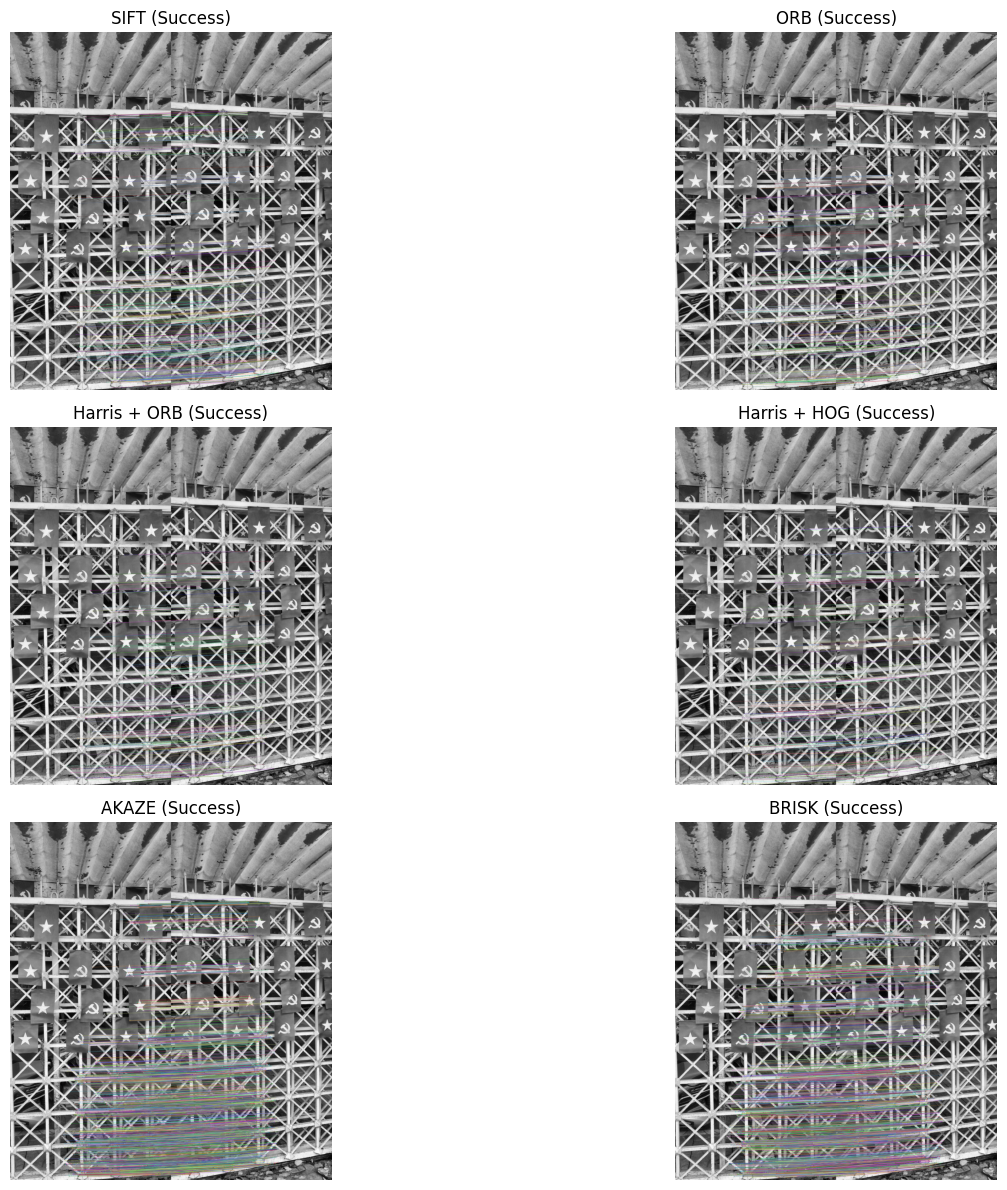

In [7]:
def show_saved_image_grid(
    dataframe: pd.DataFrame,
    path_column: str,
    title_column: str = "Pipeline",
    max_cols: int = 2,
    figsize_per_item: tuple[float, float] = (8.0, 4.0),
) -> None:
    valid_rows = dataframe[dataframe[path_column].astype(str).str.len() > 0].copy()
    if valid_rows.empty:
        print(f"No saved images found for {path_column}.")
        return

    if not HAS_MATPLOTLIB:
        print(f"Matplotlib is not installed. Saved {path_column} files:")
        for _, row in valid_rows.iterrows():
            print(f"- {row[title_column]}: {row[path_column]}")
        return

    n_items = len(valid_rows)
    cols = min(max_cols, n_items)
    rows = int(math.ceil(n_items / cols))
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(figsize_per_item[0] * cols, figsize_per_item[1] * rows),
    )
    axes_array = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes_array, valid_rows.iterrows()):
        image_path = PROJECT_ROOT / row[path_column]
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image is None:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center")
            ax.axis("off")
            continue
        display_image, _ = resize_keep_aspect(image, MAX_DISPLAY_WIDTH)
        ax.imshow(bgr_to_rgb(display_image))
        ax.set_title(f"{row[title_column]} ({row['Result']})")
        ax.axis("off")

    for ax in axes_array[n_items:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_saved_image_grid(
    results_df,
    "Match visualization",
    max_cols=2,
    figsize_per_item=(8.5, 4.0),
)


## 8. Pairwise Panorama Outputs

These panoramas are built with the same simple pairwise warp and average-overlap blend for every method. This is not OpenCV's full panorama stitcher; it is a controlled comparison of how each feature pipeline supports homography estimation from the same preprocessed inputs.

,Pipeline,Output panorama,Result,RANSAC inliers,Inlier ratio,Reprojection error,Notes
0,SIFT,outputs/case_study/development/scene_32/pair_0...,Success,412,45.9%,1.87 px,
1,ORB,outputs/case_study/development/scene_32/pair_0...,Success,343,48.7%,1.77 px,
2,Harris + ORB,outputs/case_study/development/scene_32/pair_0...,Success,223,51.9%,1.98 px,
3,Harris + HOG,outputs/case_study/development/scene_32/pair_0...,Success,214,57.8%,1.90 px,
4,AKAZE,outputs/case_study/development/scene_32/pair_0...,Success,3232,43.7%,1.66 px,
5,BRISK,outputs/case_study/development/scene_32/pair_0...,Success,3089,64.3%,1.86 px,


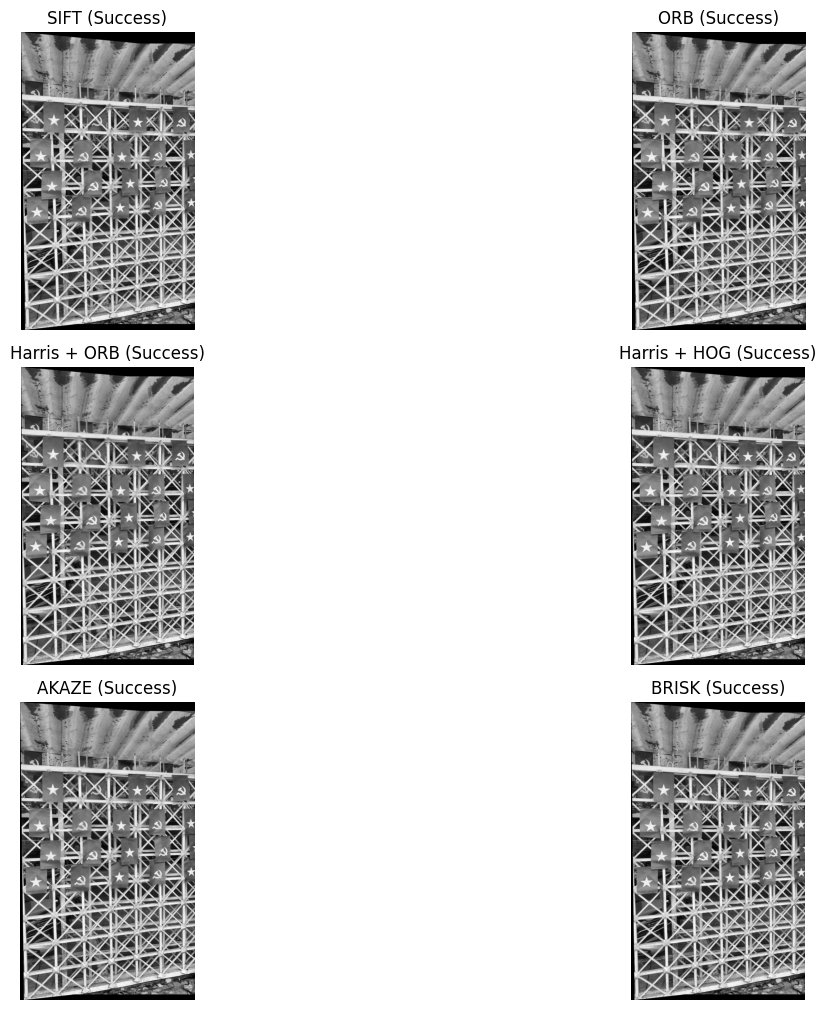

In [8]:
panorama_table = results_df[
    ["Pipeline", "Output panorama", "Result", "RANSAC inliers", "Inlier ratio", "Reprojection error", "Notes"]
].copy()
panorama_table["Inlier ratio"] = panorama_table["Inlier ratio"].map(lambda value: "" if pd.isna(value) else f"{value:.1%}")
panorama_table["Reprojection error"] = panorama_table["Reprojection error"].map(lambda value: "" if pd.isna(value) else f"{value:.2f} px")
display(panorama_table)

show_saved_image_grid(
    results_df,
    "Output panorama",
    max_cols=2,
    figsize_per_item=(8.5, 3.4),
)


## 9. Scene Interpretation

In [9]:
valid_results = results_df[
    results_df["RANSAC inliers"].notna()
    & (results_df["RANSAC inliers"] > 0)
    & results_df["Reprojection error"].notna()
].copy()

if valid_results.empty:
    display(
        Markdown(
            "No method produced a usable homography for this pair. In the report, explain this using the "
            "scene difficulty notes and the match visualizations."
        )
    )
else:
    result_rank = {"Success": 0, "Acceptable": 1, "Weak": 2, "Failed": 3, "Unavailable": 4}
    valid_results["Result rank"] = valid_results["Result"].map(result_rank).fillna(9)
    best = valid_results.sort_values(
        ["Result rank", "RANSAC inliers", "Inlier ratio", "Reprojection error"],
        ascending=[True, False, False, True],
    ).iloc[0]
    weakest = valid_results.sort_values(
        ["Result rank", "RANSAC inliers", "Inlier ratio", "Reprojection error"],
        ascending=[False, True, True, False],
    ).iloc[0]

    display(
        Markdown(
            f"### Scene interpretation\n\n"
            f"For **{SCENE_ID}**, the strongest measured pipeline was **{best['Pipeline']}**. "
            f"It produced **{int(best['RANSAC inliers'])} RANSAC inliers**, an inlier ratio of "
            f"**{best['Inlier ratio']:.1%}**, and an average reprojection error of "
            f"**{best['Reprojection error']:.2f} px**. These values indicate that its matches were "
            f"geometrically more consistent for this image pair.\n\n"
            f"The weakest measured available pipeline was **{weakest['Pipeline']}**, with "
            f"**{int(weakest['RANSAC inliers'])} inliers**, an inlier ratio of "
            f"**{weakest['Inlier ratio']:.1%}**, and reprojection error of "
            f"**{weakest['Reprojection error']:.2f} px**. Use the match visualization above to explain "
            f"whether the problem is false matches, matches concentrated in a small area, or poor alignment "
            f"after warping.\n\n"
            f"Scene condition notes from metadata: **{', '.join(active_flags)}**. "
            f"If the final panorama has duplicated edges, visible ghosting, or distorted straight lines, "
            f"connect that visual failure back to the inlier ratio and reprojection error."
        )
    )


### Scene interpretation

For **scene_32**, the strongest measured pipeline was **AKAZE**. It produced **3232 RANSAC inliers**, an inlier ratio of **43.7%**, and an average reprojection error of **1.66 px**. These values indicate that its matches were geometrically more consistent for this image pair.

The weakest measured available pipeline was **Harris + HOG**, with **214 inliers**, an inlier ratio of **57.8%**, and reprojection error of **1.90 px**. Use the match visualization above to explain whether the problem is false matches, matches concentrated in a small area, or poor alignment after warping.

Scene condition notes from metadata: **repeated patterns**. If the final panorama has duplicated edges, visible ghosting, or distorted straight lines, connect that visual failure back to the inlier ratio and reprojection error.

## 10. Case-Study Summary

This case-study page contains:

1. Scene name and preprocessed input pair
2. Scene difficulty notes: blur, low texture, repeated patterns, moving objects, exposure change, parallax
3. Quantitative table: keypoints, raw matches, good matches, RANSAC inliers, inlier ratio, reprojection error, runtime, result
4. RANSAC inlier match visualizations for each available method
5. Pairwise panorama outputs for each available method
6. Short conclusion: best method, weakest method, and the scene condition that explains the difference

The comparison should not be judged only by the number of keypoints. For stitching, the more important evidence is RANSAC inliers, inlier ratio, reprojection error, and the final panorama quality.